# Apply Calibrated Event Rules to Real BOAMP

This notebook applies the calibrated broad, balanced, and strict event-definition rules to the current real BOAMP candidate-pair table. It creates survival-ready datasets for each rule without overwriting the existing baseline handoff.

Important interpretation: real BOAMP has no certified recurrence-chain labels. `event = 1` in the outputs below is a proxy recurrence: an identifiable reappearance of a similar procurement need under the selected matching rule.


In [1]:
from __future__ import annotations

import os
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_cwd = Path.cwd()
PROJ = _cwd
for candidate in [_cwd, *_cwd.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        PROJ = candidate
        break
os.chdir(PROJ)

PROCESSED = PROJ / "data" / "processed"
REAL_OUT = PROJ / "boamp_renewal_linking_quality" / "outputs"
REPORT_TABLES = PROJ / "reports" / "tables" / "validation"
REPORT_FIGURES = PROJ / "reports" / "figures" / "validation"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

STUDY_END = pd.Timestamp("2024-12-31")
GENERIC_CPV_CODES = {"72000000", "48000000", "32000000", "35000000"}

ACADEMIC_PALETTE = ["#1b4d89", "#b85c38", "#2f6f4e", "#7a5195", "#5c677d", "#8a6f3f"]
sns.set_theme(context="paper", style="ticks", palette=ACADEMIC_PALETTE, font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "grid.color": "#d9d9d9",
    "grid.linewidth": 0.45,
    "grid.alpha": 0.7,
})

print(f"Project root: {PROJ}")


Project root: /Users/macbookair/Desktop/stage


## 1. Load Current Inputs

Inputs are the calibrated rule table, current real candidate pairs, current real link output, and current Phase 2 survival handoff. The current baseline file is read but not overwritten.


In [2]:
PATHS = {
    "recommended_rules": REPORT_TABLES / "recommended_event_rules.csv",
    "real_candidates": REAL_OUT / "boamp_renewal_candidates.csv",
    "real_links": REAL_OUT / "boamp_renewal_links.csv",
    "baseline_survival": PROCESSED / "boamp_phase2_survival.csv",
}

missing = [name for name, path in PATHS.items() if not path.exists()]
if missing:
    raise SystemExit("Missing required inputs: " + ", ".join(f"{m} -> {PATHS[m]}" for m in missing))

rules = pd.read_csv(PATHS["recommended_rules"])
candidates = pd.read_csv(PATHS["real_candidates"])
links = pd.read_csv(PATHS["real_links"])
baseline = pd.read_csv(PATHS["baseline_survival"])

inventory = pd.DataFrame([
    {"input_name": name, "file_path": str(path.relative_to(PROJ)), "rows": len(pd.read_csv(path, nrows=None)) if path.suffix == ".csv" else np.nan}
    for name, path in PATHS.items()
])
inventory.to_csv(REPORT_TABLES / "apply_calibrated_rules_input_inventory.csv", index=False)
display(inventory)
display(rules)


,input_name,file_path,rows
0,recommended_rules,reports/tables/validation/recommended_event_ru...,3
1,real_candidates,boamp_renewal_linking_quality/outputs/boamp_re...,3201
2,real_links,boamp_renewal_linking_quality/outputs/boamp_re...,1210
3,baseline_survival,data/processed/boamp_phase2_survival.csv,1210


,rule_name,text_threshold,composite_threshold,margin_threshold,W,generic_cpv_rule,real_event_count,real_linking_rate,events_available_for_survival,negative_control_pass_rate,...,easy_F1,medium_precision,medium_recall,medium_F1,hard_precision,hard_recall,hard_F1,reliability_score,expected_real_use,selection_basis
0,broad,0.4,none,none,6,generic_corrected,490,0.404959,490,0.416009,...,0.753740,0.492891,0.686016,0.573635,0.273166,0.385034,0.319593,0.469106,High recall / high linking-rate proxy-event up...,computed from synthetic reliability constraint...
1,balanced,0.5,0.5,none,6,generic_corrected,269,0.222314,269,0.094243,...,0.791293,0.600812,0.585752,0.593186,0.317597,0.302041,0.309623,0.520006,Recommended main proxy-event definition for re...,computed from synthetic reliability constraint...
2,strict,0.7,0.65,none,6,generic_corrected,79,0.065289,79,0.003549,...,0.755423,0.801858,0.341689,0.479186,0.447489,0.133333,0.205451,0.490065,High-precision robustness sensitivity with few...,computed from synthetic reliability constraint...


## 2. Validate Schemas


In [3]:
def require_columns(df: pd.DataFrame, cols: list[str], name: str):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise SystemExit(f"{name} missing columns: {missing}")

require_columns(rules, ["rule_name", "text_threshold", "composite_threshold", "margin_threshold", "W", "generic_cpv_rule"], "recommended_event_rules")
require_columns(candidates, [
    "src_idweb", "cand_idweb", "src_cpv", "cand_cpv", "src_contract_start", "cand_contract_start",
    "src_duration_months", "gap_months", "text_similarity_score", "composite_score",
], "real candidates")
require_columns(links, [
    "contract_id", "buyer_key", "contract_start", "declared_duration_months",
    "estimated_end_date", "event", "observed_duration_months",
], "real links")
require_columns(baseline, [
    "contract_id", "source", "buyer_key", "start_date", "declared_duration_months",
    "event", "observed_duration_months", "censoring_duration_months",
    "renewal_duration_months", "renewal_contract_id",
], "baseline survival")

if set(rules["rule_name"]) != {"broad", "balanced", "strict"}:
    raise SystemExit("recommended_event_rules.csv must contain exactly broad, balanced, strict.")
if links["contract_id"].duplicated().any():
    raise SystemExit("real links contain duplicated contract_id values.")
if baseline["contract_id"].duplicated().any():
    raise SystemExit("baseline survival contains duplicated contract_id values.")

checks = pd.DataFrame([
    {"check": "recommended rules loaded", "value": len(rules), "status": "PASS"},
    {"check": "candidate pairs loaded", "value": len(candidates), "status": "PASS"},
    {"check": "eligible source rows loaded", "value": len(links), "status": "PASS"},
    {"check": "baseline survival rows loaded", "value": len(baseline), "status": "PASS"},
])
checks.to_csv(REPORT_TABLES / "apply_calibrated_rules_input_checks.csv", index=False)
display(checks)


,check,value,status
0,recommended rules loaded,3,PASS
1,candidate pairs loaded,3201,PASS
2,eligible source rows loaded,1210,PASS
3,baseline survival rows loaded,1210,PASS


## 3. Rule Application Functions

The functions below mirror the calibrated scoring logic: corrected generic CPV handling, missing-CPV renormalization, temporal score with W=6, and best-candidate selection after rule thresholds.


In [4]:
def clean_cpv(value):
    if pd.isna(value):
        return None
    text = re.sub(r"\.0$", "", str(value).strip())
    digits = re.sub(r"\D", "", text)
    if len(digits) < 2:
        return None
    return digits[:8].zfill(8)

def cpv_score(src_cpv, cand_cpv, generic_rule: str):
    src = clean_cpv(src_cpv)
    cand = clean_cpv(cand_cpv)
    if src is None or cand is None:
        return np.nan
    same_div = src[:2] == cand[:2]
    src_generic = src in GENERIC_CPV_CODES or src.endswith("000000")
    cand_generic = cand in GENERIC_CPV_CODES or cand.endswith("000000")
    if generic_rule == "generic_exact_credit" and src[:8] == cand[:8]:
        return 1.0
    if src_generic or cand_generic:
        return 0.20 if same_div else 0.0
    if src[:8] == cand[:8]:
        return 1.00
    if src[:5] == cand[:5]:
        return 0.80
    if src[:4] == cand[:4]:
        return 0.60
    if src[:3] == cand[:3]:
        return 0.40
    return 0.20 if same_div else 0.0

def composite_score(text_score, cpv_s, temporal_s, buyer_s=1.0):
    if pd.isna(cpv_s):
        return (0.40 * text_score + 0.20 * temporal_s + 0.15 * buyer_s) / 0.75
    return 0.40 * text_score + 0.25 * cpv_s + 0.20 * temporal_s + 0.15 * buyer_s

def normalize_threshold(value):
    if pd.isna(value) or str(value).lower() == "none":
        return "none"
    return float(value)

def month_diff(start, end):
    return (pd.Timestamp(end) - pd.Timestamp(start)).days / 30.44

def score_candidates_for_rule(rule: pd.Series) -> pd.DataFrame:
    W = int(rule["W"])
    generic_rule = str(rule["generic_cpv_rule"])
    d = candidates.copy()
    d["text_similarity_rule"] = pd.to_numeric(d["text_similarity_score"], errors="coerce")
    d["gap_months_rule"] = pd.to_numeric(d["gap_months"], errors="coerce")
    d["src_duration_months_rule"] = pd.to_numeric(d["src_duration_months"], errors="coerce").fillna(48.0)
    deviation = (d["gap_months_rule"] - d["src_duration_months_rule"]).abs()
    d["temporal_score_rule"] = (1.0 - deviation / float(W)).clip(lower=0.0, upper=1.0)
    d["cpv_match_score_rule"] = [cpv_score(s, c, generic_rule) for s, c in zip(d["src_cpv"], d["cand_cpv"])]
    d["cpv_used_in_score_rule"] = d["cpv_match_score_rule"].notna()
    d["composite_score_rule"] = [
        composite_score(t, c, ts)
        for t, c, ts in zip(d["text_similarity_rule"], d["cpv_match_score_rule"], d["temporal_score_rule"])
    ]
    d["source_generic_cpv"] = d["src_cpv"].map(lambda x: clean_cpv(x) in GENERIC_CPV_CODES if clean_cpv(x) else False)
    d["candidate_generic_cpv"] = d["cand_cpv"].map(lambda x: clean_cpv(x) in GENERIC_CPV_CODES if clean_cpv(x) else False)
    return d

def best_links_for_rule(rule: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    text_threshold = float(rule["text_threshold"])
    composite_threshold = normalize_threshold(rule["composite_threshold"])
    margin_threshold = normalize_threshold(rule["margin_threshold"])
    scored = score_candidates_for_rule(rule)
    filtered = scored[scored["text_similarity_rule"] >= text_threshold].copy()
    if composite_threshold != "none":
        filtered = filtered[filtered["composite_score_rule"] >= float(composite_threshold)].copy()
    if filtered.empty:
        return filtered, scored
    filtered = filtered.sort_values(
        ["src_idweb", "composite_score_rule", "text_similarity_rule", "gap_months_rule"],
        ascending=[True, False, False, True],
    ).copy()
    filtered["rank"] = filtered.groupby("src_idweb").cumcount() + 1
    best = filtered[filtered["rank"].eq(1)].copy()
    second = filtered[filtered["rank"].eq(2)][["src_idweb", "composite_score_rule"]].rename(
        columns={"composite_score_rule": "second_best_composite_score_rule"}
    )
    counts = filtered.groupby("src_idweb").size().rename("n_candidates_for_source_rule")
    best = best.merge(second, on="src_idweb", how="left").merge(counts, on="src_idweb", how="left")
    best["score_margin_rule"] = best["composite_score_rule"] - best["second_best_composite_score_rule"]
    if margin_threshold != "none":
        best = best[best["score_margin_rule"].fillna(-1) >= float(margin_threshold)].copy()
    return best, scored


## 4. Generate Rule-Specific Survival Datasets


In [5]:
def build_survival_for_rule(rule: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    rule_name = str(rule["rule_name"])
    best, scored = best_links_for_rule(rule)
    best_by_contract = best.copy()
    best_by_contract["contract_id"] = "BOAMP:" + best_by_contract["src_idweb"].astype(str)
    best_by_contract["renewal_contract_id_rule"] = "BOAMP:" + best_by_contract["cand_idweb"].astype(str)
    best_by_contract = best_by_contract.set_index("contract_id", drop=False)

    out = baseline.copy()
    out["rule_name"] = rule_name
    out["event_definition"] = "calibrated_" + rule_name
    out["event"] = 0
    out["renewal_contract_id"] = np.nan
    out["renewal_duration_months"] = np.nan
    out["link_method"] = "none"
    out["composite_score"] = np.nan
    out["text_similarity"] = np.nan
    out["cpv_match_score"] = np.nan
    out["cpv_used_in_score"] = np.nan
    out["temporal_score"] = np.nan
    out["best_composite_score"] = np.nan
    out["second_best_composite_score"] = np.nan
    out["score_margin"] = np.nan
    out["n_candidates_for_source"] = 0
    out["single_candidate_match"] = False
    out["high_confidence_strict"] = False

    start_dates = pd.to_datetime(out["start_date"], errors="coerce")
    censor_durations = (STUDY_END - start_dates).dt.days / 30.44
    out["observed_duration_months"] = censor_durations.round(2)
    out["censoring_duration_months"] = out["observed_duration_months"]

    matched_mask = out["contract_id"].isin(best_by_contract.index)
    for idx, row in out.loc[matched_mask].iterrows():
        b = best_by_contract.loc[row["contract_id"]]
        out.at[idx, "event"] = 1
        out.at[idx, "renewal_contract_id"] = b["renewal_contract_id_rule"]
        out.at[idx, "observed_duration_months"] = round(float(b["gap_months_rule"]), 2)
        out.at[idx, "renewal_duration_months"] = round(float(b["gap_months_rule"]), 2)
        out.at[idx, "censoring_duration_months"] = np.nan
        out.at[idx, "link_method"] = "calibrated_rule"
        out.at[idx, "composite_score"] = round(float(b["composite_score_rule"]), 4)
        out.at[idx, "text_similarity"] = round(float(b["text_similarity_rule"]), 4)
        out.at[idx, "cpv_match_score"] = round(float(b["cpv_match_score_rule"]), 4) if pd.notna(b["cpv_match_score_rule"]) else np.nan
        out.at[idx, "cpv_used_in_score"] = bool(b["cpv_used_in_score_rule"])
        out.at[idx, "temporal_score"] = round(float(b["temporal_score_rule"]), 4)
        out.at[idx, "best_composite_score"] = round(float(b["composite_score_rule"]), 4)
        out.at[idx, "second_best_composite_score"] = round(float(b["second_best_composite_score_rule"]), 4) if pd.notna(b["second_best_composite_score_rule"]) else np.nan
        out.at[idx, "score_margin"] = round(float(b["score_margin_rule"]), 4) if pd.notna(b["score_margin_rule"]) else np.nan
        out.at[idx, "n_candidates_for_source"] = int(b["n_candidates_for_source_rule"])
        out.at[idx, "single_candidate_match"] = int(b["n_candidates_for_source_rule"]) == 1
        out.at[idx, "high_confidence_strict"] = (
            float(b["composite_score_rule"]) >= 0.70 and
            pd.notna(b["score_margin_rule"]) and float(b["score_margin_rule"]) >= 0.05
        )

    out["event"] = out["event"].astype(int)
    out["is_censored"] = (out["event"] == 0).astype(int)
    return out, best.reset_index(drop=True)

all_survival = []
all_best_links = []
summary_rows = []

for _, rule in rules.iterrows():
    survival, best = build_survival_for_rule(rule)
    rule_name = str(rule["rule_name"])
    out_path = PROCESSED / f"boamp_phase2_survival_calibrated_{rule_name}.csv"
    survival.to_csv(out_path, index=False)
    best_path = REPORT_TABLES / f"calibrated_real_best_links_{rule_name}.csv"
    best.to_csv(best_path, index=False)
    all_survival.append(survival)
    best["rule_name"] = rule_name
    all_best_links.append(best)
    ev = survival[survival["event"].eq(1)]
    summary_rows.append({
        "rule_name": rule_name,
        "text_threshold": rule["text_threshold"],
        "composite_threshold": rule["composite_threshold"],
        "margin_threshold": rule["margin_threshold"],
        "W": int(rule["W"]),
        "generic_cpv_rule": rule["generic_cpv_rule"],
        "n_rows": len(survival),
        "n_events": int(survival["event"].sum()),
        "n_censored": int((survival["event"] == 0).sum()),
        "event_rate": float(survival["event"].mean()),
        "median_text_similarity": float(ev["text_similarity"].median()) if len(ev) else np.nan,
        "median_composite_score": float(ev["composite_score"].median()) if len(ev) else np.nan,
        "median_score_margin": float(ev["score_margin"].median()) if ev["score_margin"].notna().any() else np.nan,
        "n_high_confidence_strict": int(ev["high_confidence_strict"].sum()) if len(ev) else 0,
        "survival_dataset": str(out_path.relative_to(PROJ)),
        "best_links_table": str(best_path.relative_to(PROJ)),
    })

survival_long = pd.concat(all_survival, ignore_index=True)
best_links_long = pd.concat(all_best_links, ignore_index=True)
summary = pd.DataFrame(summary_rows)

survival_long.to_csv(PROCESSED / "boamp_phase2_survival_calibrated_rules_long.csv", index=False)
best_links_long.to_csv(REPORT_TABLES / "calibrated_real_best_links_all_rules.csv", index=False)
summary.to_csv(REPORT_TABLES / "calibrated_real_event_definition_summary.csv", index=False)
display(summary)


,rule_name,text_threshold,composite_threshold,margin_threshold,W,generic_cpv_rule,n_rows,n_events,n_censored,event_rate,median_text_similarity,median_composite_score,median_score_margin,n_high_confidence_strict,survival_dataset,best_links_table
0,broad,0.4,none,none,6,generic_corrected,1210,490,720,0.404959,0.52985,0.55105,0.05515,44,data/processed/boamp_phase2_survival_calibrate...,reports/tables/validation/calibrated_real_best...
1,balanced,0.5,0.5,none,6,generic_corrected,1210,269,941,0.222314,0.62910,0.62430,0.04815,23,data/processed/boamp_phase2_survival_calibrate...,reports/tables/validation/calibrated_real_best...
2,strict,0.7,0.65,none,6,generic_corrected,1210,79,1131,0.065289,0.84650,0.80620,0.03190,1,data/processed/boamp_phase2_survival_calibrate...,reports/tables/validation/calibrated_real_best...


## 5. Survival Readiness Checks


In [6]:
readiness_rows = []
for rule_name, grp in survival_long.groupby("rule_name"):
    events = int(grp["event"].sum())
    n = len(grp)
    duration = pd.to_numeric(grp["observed_duration_months"], errors="coerce")
    readiness_rows.append({
        "rule_name": rule_name,
        "n_rows": n,
        "n_events": events,
        "event_rate": events / n if n else np.nan,
        "duration_missing": int(duration.isna().sum()),
        "duration_nonpositive": int((duration <= 0).sum()),
        "duplicate_contract_id": int(grp["contract_id"].duplicated().sum()),
        "event_without_renewal_id": int(grp.loc[grp["event"].eq(1), "renewal_contract_id"].isna().sum()),
        "cox_aft_event_count_status": "OK" if events >= 100 else "LOW_EVENTS",
        "recommended_use": rules.set_index("rule_name").loc[rule_name, "expected_real_use"],
    })

readiness = pd.DataFrame(readiness_rows)
readiness.to_csv(REPORT_TABLES / "calibrated_survival_readiness.csv", index=False)
display(readiness)

if (readiness[["duration_missing", "duration_nonpositive", "duplicate_contract_id", "event_without_renewal_id"]] != 0).any().any():
    raise SystemExit("Survival readiness check failed.")


,rule_name,n_rows,n_events,event_rate,duration_missing,duration_nonpositive,duplicate_contract_id,event_without_renewal_id,cox_aft_event_count_status,recommended_use
0,balanced,1210,269,0.222314,0,0,0,0,OK,Recommended main proxy-event definition for re...
1,broad,1210,490,0.404959,0,0,0,0,OK,High recall / high linking-rate proxy-event up...
2,strict,1210,79,0.065289,0,0,0,0,LOW_EVENTS,High-precision robustness sensitivity with few...


## 6. Figures


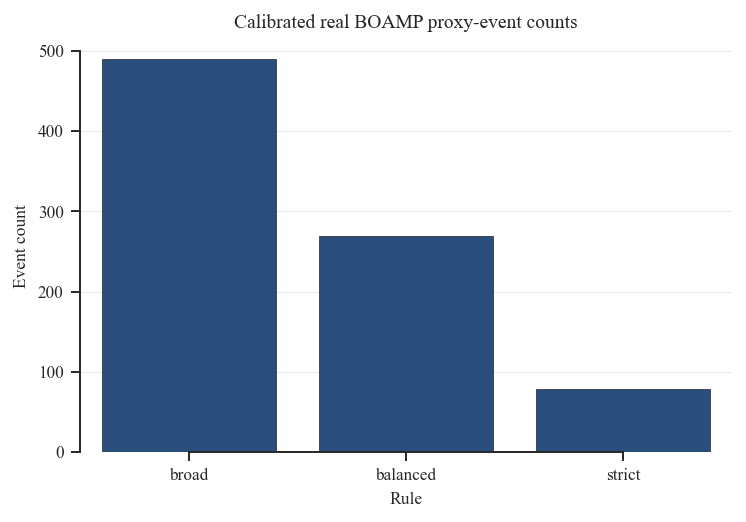

/Users/macbookair/Desktop/stage/reports/figures/validation/calibrated_real_event_counts.png


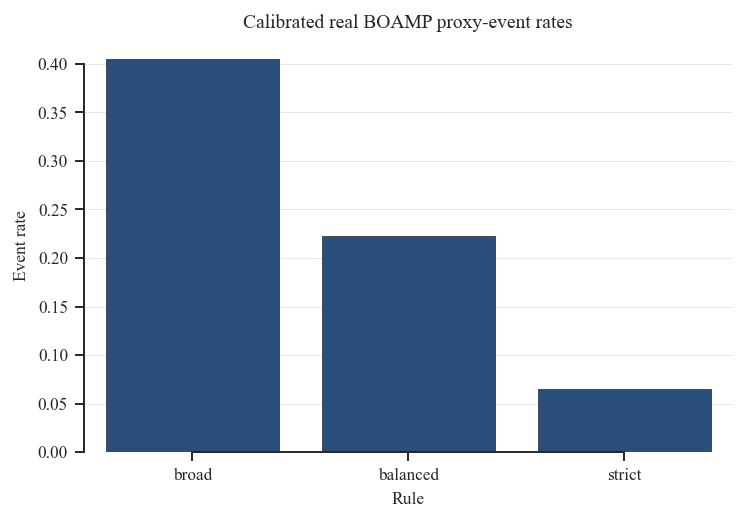

/Users/macbookair/Desktop/stage/reports/figures/validation/calibrated_real_event_rates.png


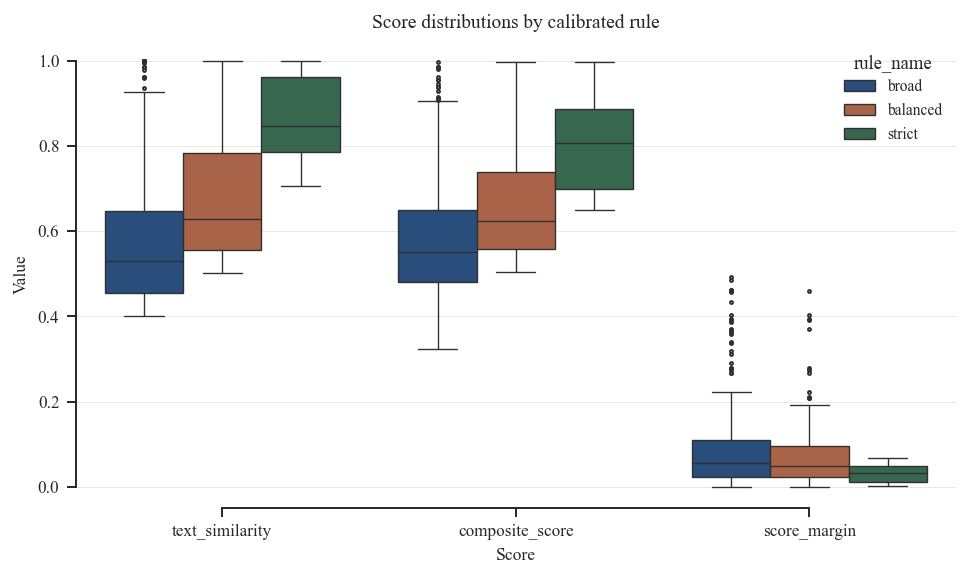

/Users/macbookair/Desktop/stage/reports/figures/validation/calibrated_real_score_distributions.png


In [7]:
def style_axes(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, color="#d9d9d9", linewidth=0.45, alpha=0.7)
    ax.grid(False, axis="x" if grid_axis == "y" else "y")
    sns.despine(ax=ax, trim=True)
    return ax

def savefig(name):
    fig = plt.gcf()
    for ax in fig.axes:
        style_axes(ax)
    path = REPORT_FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(path)

plt.figure(figsize=(5.4, 3.8))
sns.barplot(data=summary, x="rule_name", y="n_events", edgecolor="#222222", linewidth=0.35)
plt.title("Calibrated real BOAMP proxy-event counts")
plt.xlabel("Rule")
plt.ylabel("Event count")
savefig("calibrated_real_event_counts.png")

plt.figure(figsize=(5.4, 3.8))
sns.barplot(data=summary, x="rule_name", y="event_rate", edgecolor="#222222", linewidth=0.35)
plt.title("Calibrated real BOAMP proxy-event rates")
plt.xlabel("Rule")
plt.ylabel("Event rate")
savefig("calibrated_real_event_rates.png")

score_plot = survival_long[survival_long["event"].eq(1)].copy()
score_plot = score_plot.melt(
    id_vars=["rule_name"],
    value_vars=["text_similarity", "composite_score", "score_margin"],
    var_name="score_type",
    value_name="value",
)
plt.figure(figsize=(7.0, 4.2))
sns.boxplot(data=score_plot, x="score_type", y="value", hue="rule_name", linewidth=0.7, fliersize=1.5)
plt.title("Score distributions by calibrated rule")
plt.xlabel("Score")
plt.ylabel("Value")
savefig("calibrated_real_score_distributions.png")


## 7. Final Verification and Summary


In [8]:
expected_files = [
    PROCESSED / "boamp_phase2_survival_calibrated_broad.csv",
    PROCESSED / "boamp_phase2_survival_calibrated_balanced.csv",
    PROCESSED / "boamp_phase2_survival_calibrated_strict.csv",
    PROCESSED / "boamp_phase2_survival_calibrated_rules_long.csv",
    REPORT_TABLES / "calibrated_real_event_definition_summary.csv",
    REPORT_TABLES / "calibrated_survival_readiness.csv",
    REPORT_TABLES / "calibrated_real_best_links_all_rules.csv",
    REPORT_FIGURES / "calibrated_real_event_counts.png",
    REPORT_FIGURES / "calibrated_real_event_rates.png",
    REPORT_FIGURES / "calibrated_real_score_distributions.png",
]

verification = pd.DataFrame([
    {"file": str(path.relative_to(PROJ)), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
    for path in expected_files
])
verification["status"] = np.where(verification["exists"] & (verification["size_bytes"] > 0), "PASS", "FAIL")
verification.to_csv(REPORT_TABLES / "apply_calibrated_rules_verification.csv", index=False)
display(verification)

if (verification["status"] != "PASS").any():
    raise SystemExit("Output verification failed.")

balanced = summary[summary["rule_name"].eq("balanced")].iloc[0]
print("FINAL STATUS: PASS")
print(f"Balanced survival dataset: data/processed/boamp_phase2_survival_calibrated_balanced.csv")
print(f"Balanced events: {int(balanced['n_events'])} / {int(balanced['n_rows'])} ({balanced['event_rate']:.1%})")
print("Next step: rerun survival analysis using the balanced dataset as main, with broad and strict as sensitivity definitions.")


,file,exists,size_bytes,status
0,data/processed/boamp_phase2_survival_calibrate...,True,290286,PASS
1,data/processed/boamp_phase2_survival_calibrate...,True,283368,PASS
2,data/processed/boamp_phase2_survival_calibrate...,True,266991,PASS
3,data/processed/boamp_phase2_survival_calibrate...,True,839443,PASS
4,reports/tables/validation/calibrated_real_even...,True,934,PASS
5,reports/tables/validation/calibrated_survival_...,True,508,PASS
6,reports/tables/validation/calibrated_real_best...,True,384078,PASS
7,reports/figures/validation/calibrated_real_eve...,True,49038,PASS
8,reports/figures/validation/calibrated_real_eve...,True,55640,PASS
9,reports/figures/validation/calibrated_real_sco...,True,73843,PASS


FINAL STATUS: PASS
Balanced survival dataset: data/processed/boamp_phase2_survival_calibrated_balanced.csv
Balanced events: 269 / 1210 (22.2%)
Next step: rerun survival analysis using the balanced dataset as main, with broad and strict as sensitivity definitions.


## Conclusion

The calibrated datasets are now ready for the survival rerun:

- broad: high-recall / high-linking-rate sensitivity;
- balanced: main proxy-event definition;
- strict: high-precision robustness sensitivity.

The original `data/processed/boamp_phase2_survival.csv` baseline was not overwritten. Real BOAMP event labels remain proxy recurrences, not certified recurrence chains.
